<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


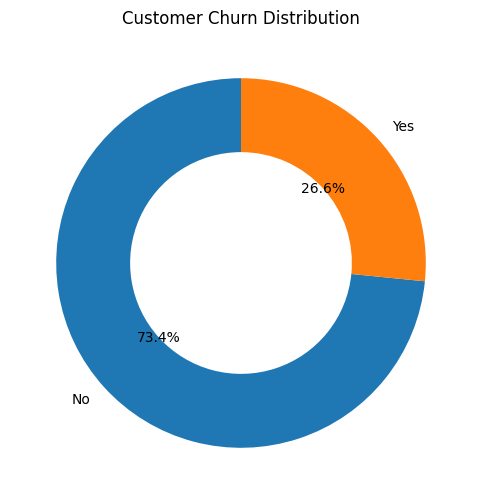

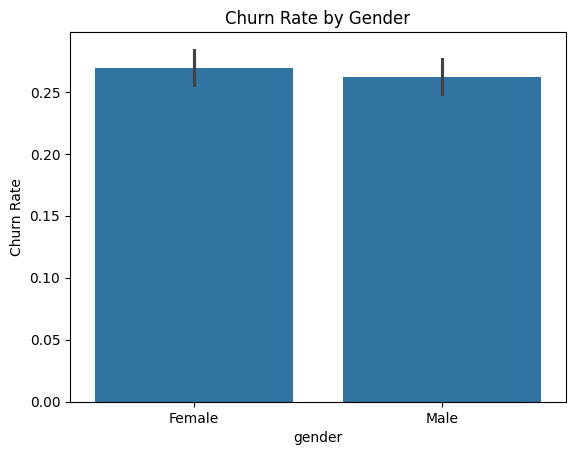

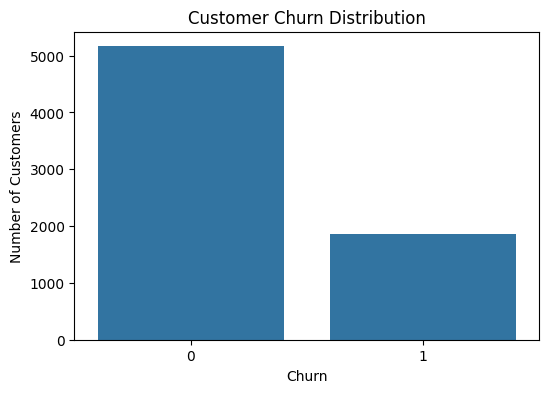

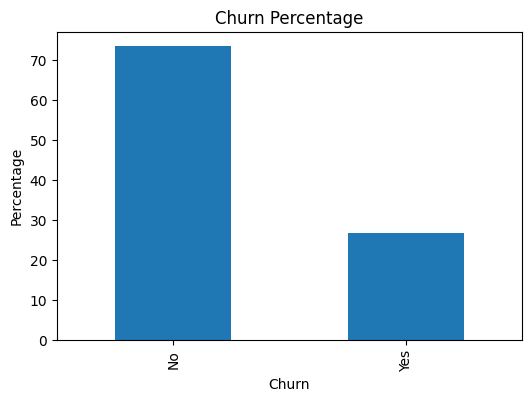

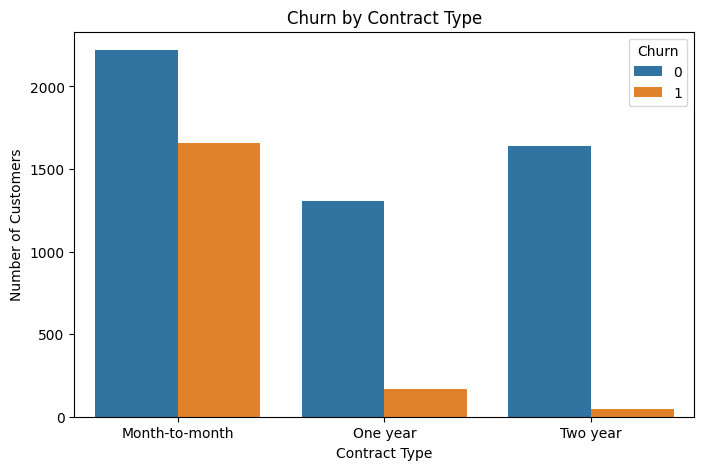

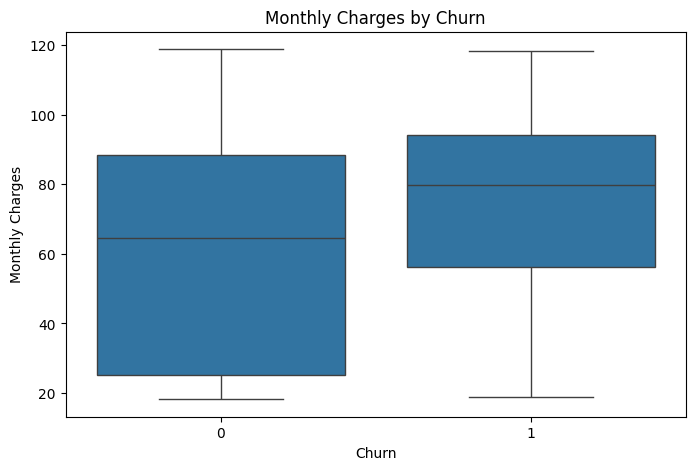

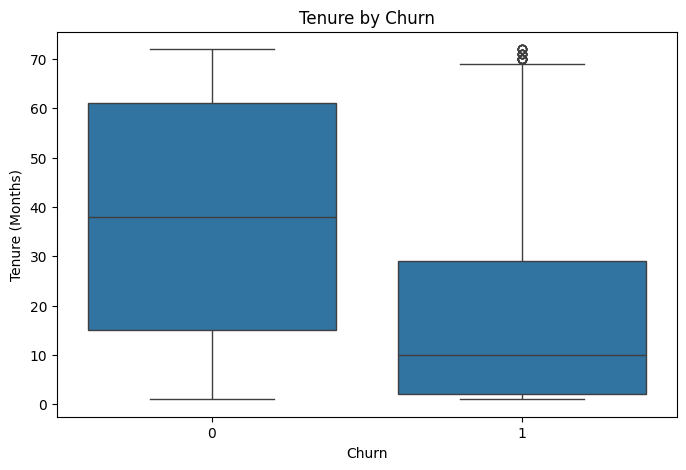

Categorical columns: ['Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Accuracy: 0.8038379530916845

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407


Confusion Matrix:
[[916 117]
 [159 215]]
Random Forest Results:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.62       374

    accuracy                           0.74      1407
   ma

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

df = pd.read_csv("churndb.csv")
df.head()
df.shape
df.info()
df.describe()


# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Check missing values
print(df.isna().sum())

# Remove missing TotalCharges
df = df.dropna(subset=["TotalCharges"])

# Check again
print(df.isna().sum())


df["Churn"].value_counts()
df["Churn"].value_counts(normalize=True) * 100

churn_percent = df["Churn"].value_counts(normalize=True) * 100
churn_counts = df["Churn"].value_counts()

df["Churn"]=df["Churn"].map({"No":0,"Yes":1})


#--------------------------------------

plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)



plt.title("Customer Churn Distribution")

plt.show()

#--------------------------------------
sns.barplot(
    data=df,
    x="gender",
    y="Churn"
)

plt.title("Churn Rate by Gender")
plt.ylabel("Churn Rate")
plt.show()
#--------------------------------------

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()
#--------------------------------------

plt.figure(figsize=(6, 4))

churn_percent.plot(kind="bar")

plt.title("Churn Percentage")
plt.xlabel("Churn")
plt.ylabel("Percentage")

plt.show()
#--------------------------------------
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()
#--------------------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()
#--------------------------------------
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()
#--------------------------------------



X = df.drop(columns=["customerID", "Churn", "gender"])
y = df["Churn"]

catCol = X.select_dtypes(include=["object"]).columns.tolist()
numCol = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", catCol)
print("Numerical columns:", numCol)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numCol),
    ("cat", categorical_pipeline, catCol)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)
y_pred = logistic_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))


gradient_boosting_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gradient_boosting_model.fit(X_train, y_train)

gb_pred = gradient_boosting_model.predict(X_test)

print("Gradient Boosting Results")
print(classification_report(y_test, gb_pred))
print(confusion_matrix(y_test, gb_pred))
#-----------------------------------------------------------------

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ))
])

decision_tree_model.fit(X_train, y_train)

dt_pred = decision_tree_model.predict(X_test)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(classification_report(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))


In [47]:
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

train_pred = random_forest_model.predict(X_train)
test_pred = random_forest_model.predict(X_test)

print("TRAINING RESULTS")
print("Accuracy:", accuracy_score(y_train, train_pred))
print("Recall:", recall_score(y_train, train_pred))

print("\nTESTING RESULTS")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Recall:", recall_score(y_test, test_pred))

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, test_pred))

print("\nCONFUSION MATRIX")
print(confusion_matrix(y_test, test_pred))

TRAINING RESULTS
Accuracy: 0.7939555555555555
Recall: 0.8448160535117056

TESTING RESULTS
Accuracy: 0.7448471926083866
Recall: 0.7727272727272727

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.77      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407


CONFUSION MATRIX
[[759 274]
 [ 85 289]]
